### HW 2

1

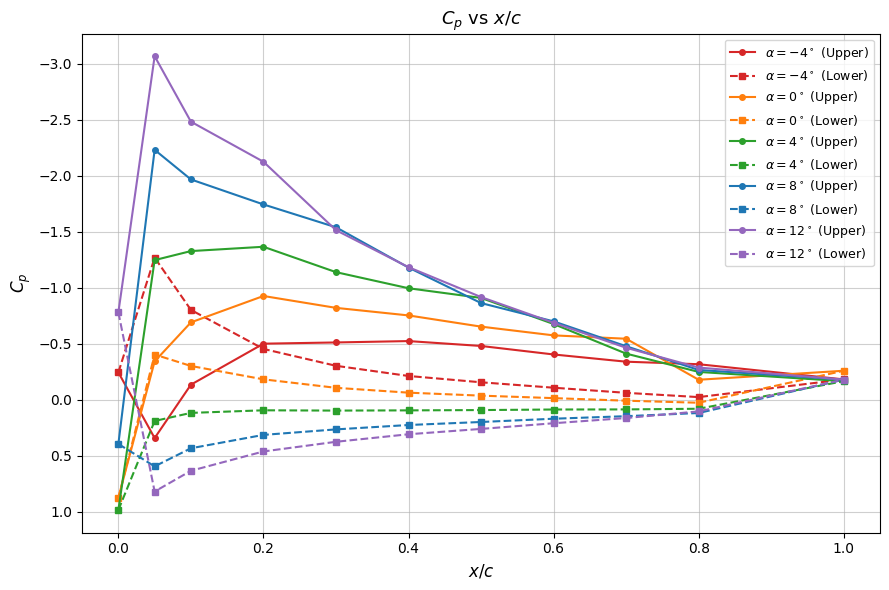

In [1]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd


df_raw = pd.read_csv("ABP_2.csv", header=None, skiprows=2)


upper_slice = slice(9, 20)  # Upper surface (cols 9 to 19)
lower_slice = slice(19, 30)  # Lower surface (cols 19 to 29)

x_c_upper = df_raw.iloc[0, upper_slice].to_numpy(dtype=float)
x_c_lower = df_raw.iloc[0, lower_slice].to_numpy(dtype=float)


upper_sort = np.argsort(x_c_upper)
lower_sort = np.argsort(x_c_lower)


data = df_raw.iloc[2:].copy()
aoa_col = 1  
q_col = 2  

target_aoas = [-4, 0, 4, 8, 12]


plt.figure(figsize=(9, 6))
colors = ["tab:red", "tab:orange", "tab:green", "tab:blue", "tab:purple"]

for aoa, color in zip(target_aoas, colors):

    row = data[data[aoa_col].astype(float) == aoa]

    if not row.empty:
        q_wt = float(row[q_col].values[0])
        p_upper = row.iloc[0, upper_slice].to_numpy(dtype=float)
        p_lower = row.iloc[0, lower_slice].to_numpy(dtype=float)


        cp_upper = p_upper / q_wt
        cp_lower = p_lower / q_wt


        plt.plot(
            x_c_upper[upper_sort],
            cp_upper[upper_sort],
            marker="o",
            markersize=4,
            linestyle="-",
            color=color,
            label=f"$\\alpha = {aoa}^\\circ$ (Upper)",
        )


        plt.plot(
            x_c_lower[lower_sort],
            cp_lower[lower_sort],
            marker="s",
            markersize=4,
            linestyle="--",
            color=color,
            label=f"$\\alpha = {aoa}^\\circ$ (Lower)",
        )

plt.gca().invert_yaxis() #invert
plt.xlabel("$x/c$", fontsize=12)
plt.ylabel("$C_p$", fontsize=12)
plt.title(
    "$C_p$ vs $x/c$",
    fontsize=13,
)
plt.grid(True, alpha=0.6)
plt.legend(loc="best", fontsize=9)
plt.tight_layout()



plt.show()

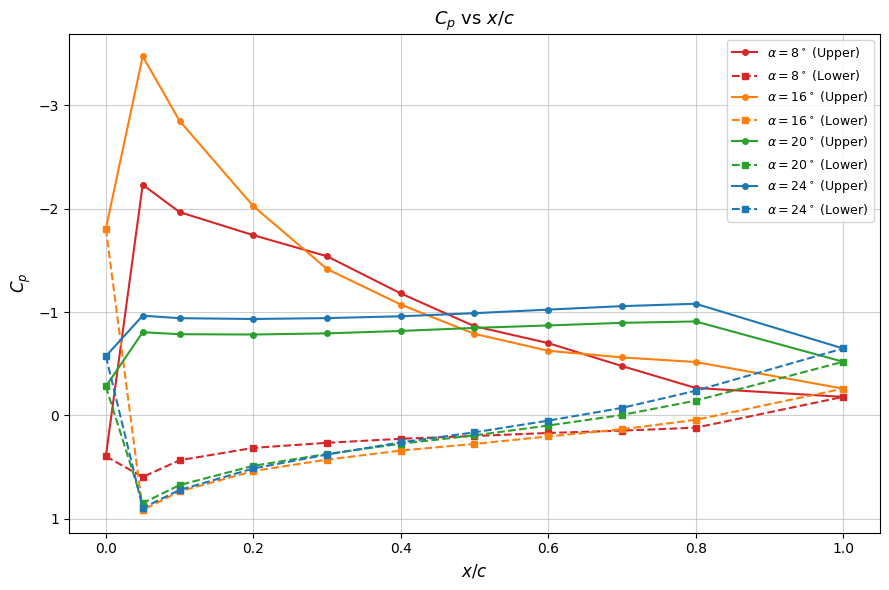

In [2]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd


df_raw = pd.read_csv("ABP_2.csv", header=None, skiprows=2)


upper_slice = slice(9, 20)  # Upper surface (cols 9 to 19)
lower_slice = slice(19, 30)  # Lower surface (cols 19 to 29)

x_c_upper = df_raw.iloc[0, upper_slice].to_numpy(dtype=float)
x_c_lower = df_raw.iloc[0, lower_slice].to_numpy(dtype=float)


upper_sort = np.argsort(x_c_upper)
lower_sort = np.argsort(x_c_lower)


data = df_raw.iloc[2:].copy()
aoa_col = 1  
q_col = 2  

target_aoas = [8,16,20,24]


plt.figure(figsize=(9, 6))
colors = ["tab:red", "tab:orange", "tab:green", "tab:blue", "tab:purple"]

for aoa, color in zip(target_aoas, colors):

    row = data[data[aoa_col].astype(float) == aoa]

    if not row.empty:
        q_wt = float(row[q_col].values[0])
        p_upper = row.iloc[0, upper_slice].to_numpy(dtype=float)
        p_lower = row.iloc[0, lower_slice].to_numpy(dtype=float)


        cp_upper = p_upper / q_wt
        cp_lower = p_lower / q_wt


        plt.plot(
            x_c_upper[upper_sort],
            cp_upper[upper_sort],
            marker="o",
            markersize=4,
            linestyle="-",
            color=color,
            label=f"$\\alpha = {aoa}^\\circ$ (Upper)",
        )


        plt.plot(
            x_c_lower[lower_sort],
            cp_lower[lower_sort],
            marker="s",
            markersize=4,
            linestyle="--",
            color=color,
            label=f"$\\alpha = {aoa}^\\circ$ (Lower)",
        )

plt.gca().invert_yaxis() #invert
plt.xlabel("$x/c$", fontsize=12)
plt.ylabel("$C_p$", fontsize=12)
plt.title(
    "$C_p$ vs $x/c$",
    fontsize=13,
)
plt.grid(True, alpha=0.6)
plt.legend( loc="best", fontsize=9)
plt.tight_layout()


plt.show()

In [3]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd


df_raw = pd.read_csv("ABP_2.csv", header=None, skiprows=2)


upper_slice = slice(9, 20)  # Upper surface (cols 9 to 19)
lower_slice = slice(19, 30)  # Lower surface (cols 19 to 29)

x_c_upper = df_raw.iloc[0, upper_slice].to_numpy(dtype=float)
x_c_lower = df_raw.iloc[0, lower_slice].to_numpy(dtype=float)

y_c_upper = df_raw.iloc[1, upper_slice].to_numpy(dtype=float)
y_c_lower = df_raw.iloc[1, lower_slice].to_numpy(dtype=float)


upper_sort = np.argsort(x_c_upper)
lower_sort = np.argsort(x_c_lower)


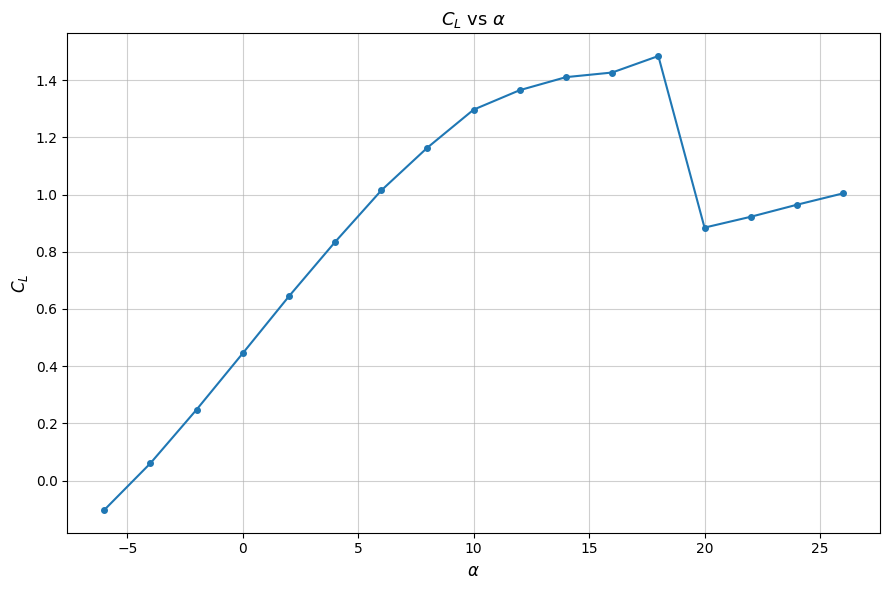

In [18]:
import numpy as np
import pandas as pd


df_header = pd.read_csv("ABP_2.csv", skiprows=3, nrows=2, header=None)
xc = df_header.iloc[0, 9:].astype(float).values  
yc = df_header.iloc[1, 9:].astype(float).values 


df_data = pd.read_csv("ABP_2.csv", skiprows=5, header=None)

results = []

for _, row in df_data.iterrows():
  aoa_deg = float(row[1])
  alpha_rad = np.radians(aoa_deg)
  q_wt = float(row[2])
  p_taps = row.iloc[9:].astype(float).values


  Cp = p_taps / q_wt


  Cp_avg = 0.5 * (Cp[:-1] + Cp[1:])


  d_xc = xc[1:] - xc[:-1]
  d_yc = yc[1:] - yc[:-1]


  C_n = np.sum(Cp_avg * d_xc)
  C_a = -np.sum(Cp_avg * d_yc)


  c_l = C_n * np.cos(alpha_rad) - C_a * np.sin(alpha_rad)
  c_d = C_n * np.sin(alpha_rad) + C_a * np.cos(alpha_rad)

  results.append({
      "AOA [deg]": aoa_deg,
      "C_n": C_n,
      "C_a": C_a,
      "c_l": c_l,
      "c_d": c_d,
  })

df_aero = pd.DataFrame(results)
#print(df_aero.to_string(index=False))
plt.figure(figsize=(9, 6))
plt.plot(
            df_aero["AOA [deg]"],
            df_aero["c_l"],
            marker="o",
            markersize=4,
        )
plt.xlabel("$\\alpha$", fontsize=12)
plt.ylabel("$C_L$", fontsize=12)
plt.title(
    "$C_L$ vs $\\alpha$",
    fontsize=13,
)
plt.grid(True, alpha=0.6)
plt.tight_layout()

plt.show()



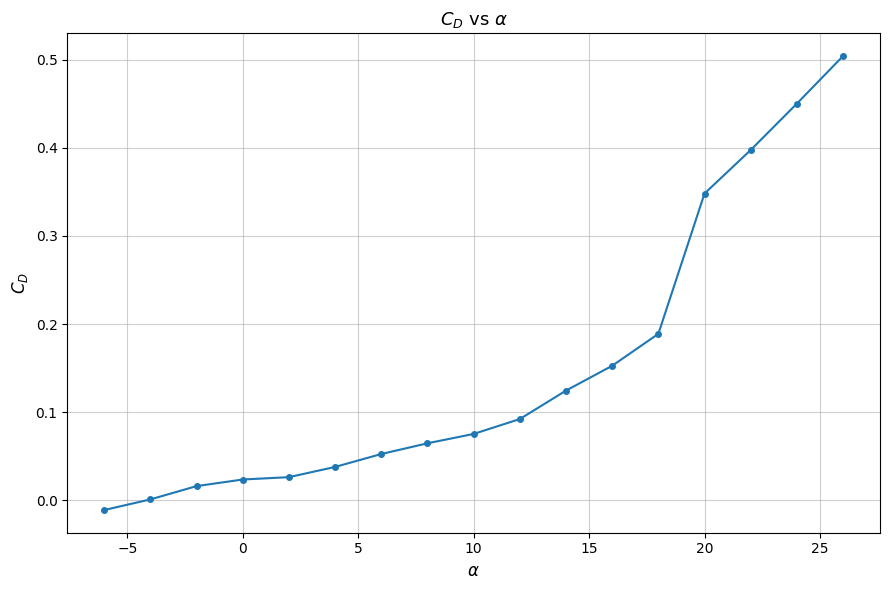

In [17]:
plt.figure(figsize=(9, 6))
plt.plot(
            df_aero["AOA [deg]"],
            df_aero["c_d"],
            marker="o",
            markersize=4,
        )
plt.xlabel("$\\alpha$", fontsize=12)
plt.ylabel("$C_D$", fontsize=12)
plt.title(
    "$C_D$ vs $\\alpha$",
    fontsize=13,
)
plt.grid(True, alpha=0.6)
plt.tight_layout()

plt.show()